170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 122ms/step - accuracy: 0.3859 - loss: 1.7758 - val_accuracy: 0.3848 - val_loss: 1.8404
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 121ms/step - accuracy: 0.4854 - loss: 1.4354 - val_accuracy: 0.4605 - val_loss: 1.6001
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 122ms/step - accuracy: 0.5224 - loss: 1.3373 - val_accuracy: 0.6107 - val_loss: 1.0843
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 123ms/step - accuracy: 0.5551 - loss: 1.2579 - val_accuracy: 0.6058 - val_loss: 1.1873
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 190s 122ms/step - accuracy: 0.5694 - loss: 1.2205 - val_accuracy: 0.6354 - val_loss: 1.0427
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 120ms/step - accuracy: 0.5808 - loss: 1.1844 - val_accuracy: 0.6501 - val_loss: 0.9820
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 120ms/step - accuracy: 0.6013 - loss: 1.1415 - val_accuracy: 0.6423 - val_loss: 1.0478
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 120ms/step - ac

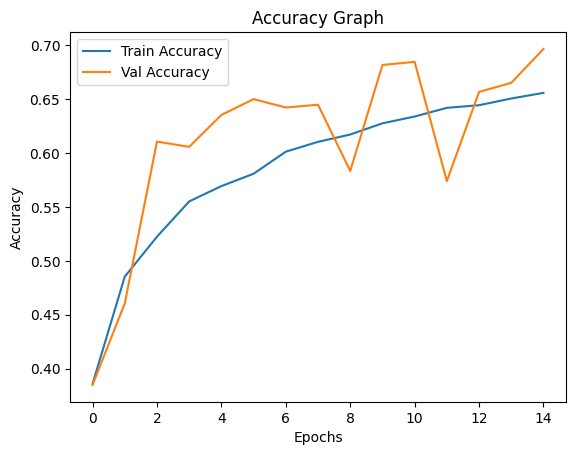

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6967 - loss: 0.8584

Test Accuracy: 0.6966999769210815
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


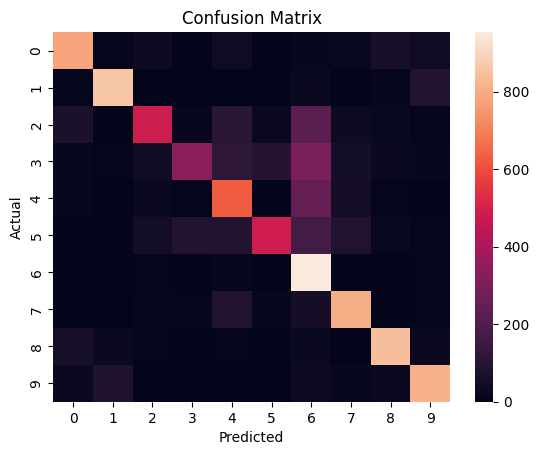

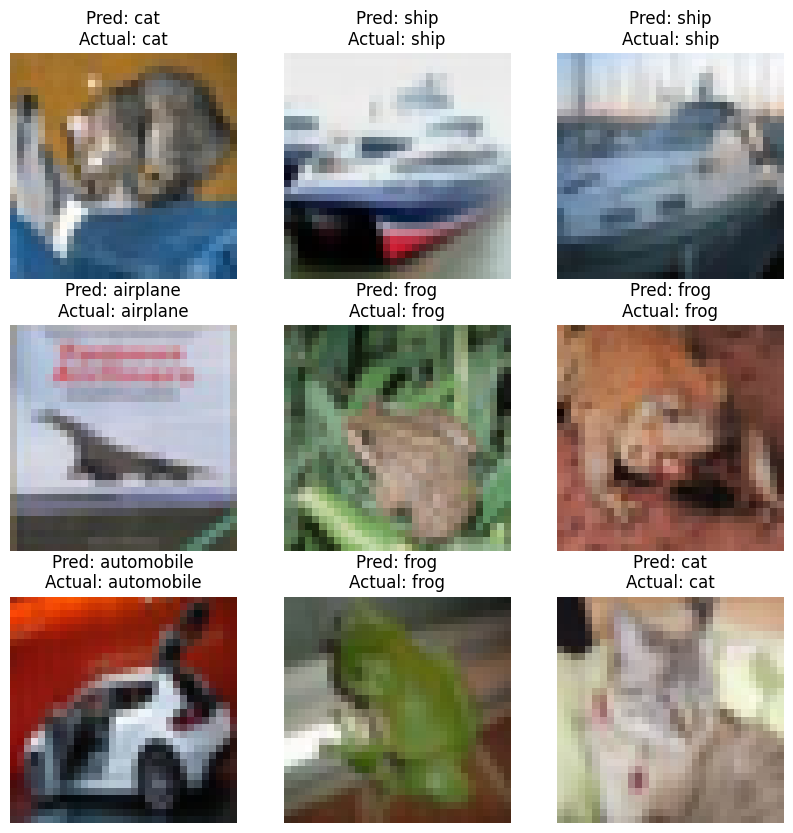

In [1]:




import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------
# 1. Load Data
# -----------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize
X_train, X_test = X_train/255.0, X_test/255.0

# -----------------------------
# 2. Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# -----------------------------
# 3. CNN Architecture
# -----------------------------
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# -----------------------------
# 4. Compile Model
# -----------------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------------
# 5. Train Model
# -----------------------------
history = model.fit(X_train, y_train,
                    epochs=15,
                    validation_data=(X_test, y_test))

# -----------------------------
# 6. Accuracy Graph
# -----------------------------
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# -----------------------------
# 7. Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

# -----------------------------
# 8. Predictions
# -----------------------------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# -----------------------------
# 9. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 10. Visualization of Predictions
# -----------------------------
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}\nActual: {class_names[y_test[i][0]]}")
    plt.axis('off')
plt.show()